# **Caso de Estudio**

## **1. Entendimiendo del problema**

## **OBJETIVO**

Vamos a emigrara a Australia y queremos conocer las mejores propuestas laborales relaciondaas con puestos de tecnologia.

Para ello, se requiere realizar un modelo predictivo para concer en que rubro sector o empresa se encuentran las mejores propuestas.

## CONTEXTO COMERCIAL

Vamos a trabajar con una base de datos de trabajos de Australia. Dentro de las varialbes a tener en cuenta vamos encontrar: Salario, Compania, Sector, Requerimientos laborales (sql, python, tableu, etc) como tambien una puntutacion en relacion al entorno laboral (Oportunidades Laborales, Valores y Cultura, entre otros)

## PROBLEMA COMERCIAL

¿Cual es la seleccion optima de trabajo si se quiere conseguir un sueldo alto y muy buenas condiciones laborales?

##**2. Extracción de los datos**

Se va a trabajar con una base de datos en Excel, con puestos de trabajo de Australia.

Vamos a enocntar variables, numericas (float, int64) categoricas y booleanas

In [ ]:
## En este colab vamos a trabajar con 3 librerias: MATPLOT, SEABORN, BOKHE

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [ ]:
# Dataset público de Kaggle/Glassdoor: "Australia Data Science Jobs" (AustraliaDataScienceJobs.csv)
df = pd.read_csv("AustraliaDataScienceJobs.csv")

In [ ]:
df.info()

In [ ]:
datajobs = df

Segmentacion de varialbes

Dimensiones:
+ [0]**Country:** Pais donde se encuentra (Objt)
+ [0]**State:** Estado donde se encuentra (Objt)
+ [0] **Job Title:** Titulo del puesto de trabajo (objt)
+ [0]**Job location:** ubicación del puesto de trabajo (objt)
+ [0]**Company:** nombre de la empresa (objt)
|
+ [181] **Company size:** cantidad de empleados (objt)
+ [567] **Company sector:** sector de la empresa (objt)
+ [3] **Job title:** nombre del puesto de trabajo (objt)

+ todas las medidasd de requerimientos: yn

Medidas:

+ [0]**Estimate Base Salary:** salario base estimado (int64)
+ [0]**Low Estimate:** salario minimo estimado (int64)
+ [0]**High Estimate:** salario maximo estimado (int64)
+ [311] **Company rating:** calificación de la empresa (float64)
+ [356] **Company friend recommendation:** recomendación de amistad de la empresa (float64)
+ [764] **Company CEO approval:** aprobación del CEO de la empresa (float64)
+ [311] **Company number of raters:** número de ratadores de la empresa (float64)
+ [318] **Company career opportunities:** oportunidades de carrera de la empresa (float64)
+ [318] **Compensation and benefits:** beneficios de compensación de la empresa (float64)
+ [318] **Company culture and values:** cultura y valores de la empresa (float64)
+ [318] **Company senior management:** gerencia de la empresa (float64)
+ [318] **Company work life balance:** equilibrio de trabajo de la empresa (float64)

In [ ]:
df = df.drop(1464, axis=0)


## **3.Limpieza de datos**



*   Estrategia para manejo de datos nulos

*   Manejo de outliers




### **3.1. Comprendiendo Varialbes**

In [ ]:
df

,Job Title,Job Location,Company,Url,Estimate Base Salary,Low Estimate,High Estimate,Company Size,Company Type,Company Sector,...,cassandra_yn,hive_yn,bigml_yn,tableau_yn,powerbi_yn,nlp_yn,pytorch_yn,tensorflow_yn,mathematic_yn,statistic_yn
0,Analyst,Melbourne,ANZ Banking Group,https://www.glassdoor.com.au/partner/jobListin...,95917,80000,115000,10000+ Employees,Company - Public,Finance,...,0,0,0,0,0,0,0,0,1,0
1,Clinical Research Associate,Mulgrave,Bristol Myers Squibb,https://www.glassdoor.com.au/partner/jobListin...,96555,79000,118000,10000+ Employees,Company - Public,Pharmaceutical & Biotechnology,...,0,0,0,0,0,0,0,0,0,0
2,Clinical Research Associate,Mulgrave,Bristol Myers Squibb,https://www.glassdoor.com.au/partner/jobListin...,96555,79000,118000,10000+ Employees,Company - Public,Pharmaceutical & Biotechnology,...,0,0,0,0,0,0,0,0,0,0
3,Clinical Research Associate,Mulgrave,Bristol Myers Squibb,https://www.glassdoor.com.au/partner/jobListin...,96555,79000,118000,10000+ Employees,Company - Public,Pharmaceutical & Biotechnology,...,0,0,0,0,0,0,0,0,0,0
4,Data Scientist,Melbourne,ANZ Banking Group,https://www.glassdoor.com.au/partner/jobListin...,115631,94000,143000,10000+ Employees,Company - Public,Finance,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2083,Helicopter Pilot,Subiaco,Rocketmine,https://www.glassdoor.com.au/partner/jobListin...,80000,70000,90000,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2084,Graduate Environmental Specialist,Perth,Lynas Corporation,https://www.glassdoor.com.au/partner/jobListin...,114923,94000,140000,501 to 1000 Employees,Company - Private,NaN,...,0,0,0,0,0,0,0,0,0,0
2085,Graduate Environmental Specialist,Perth,Lynas Corporation,https://www.glassdoor.com.au/partner/jobListin...,114923,94000,140000,501 to 1000 Employees,Company - Private,NaN,...,0,0,0,0,0,0,0,0,0,0
2086,Data Analyst,Jandakot,Schlumberger,https://www.glassdoor.com.au/partner/jobListin...,135861,108000,171000,10000+ Employees,Company - Public,"Energy, Mining, Utilities",...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2087 entries, 0 to 2087
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Job Title                      2085 non-null   object 
 1   Job Location                   2087 non-null   object 
 2   Company                        2087 non-null   object 
 3   Url                            2087 non-null   object 
 4   Estimate Base Salary           2087 non-null   int64  
 5   Low Estimate                   2087 non-null   int64  
 6   High Estimate                  2087 non-null   int64  
 7   Company Size                   1906 non-null   object 
 8   Company Type                   1906 non-null   object 
 9   Company Sector                 1520 non-null   object 
 10  Company Founded                1197 non-null   float64
 11  Company Industry               1520 non-null   object 
 12  Company Revenue                1906 non-null   o

In [ ]:
columnas_a_sumar = df.iloc[:, 25:51]  # Selecciona todas las filas de las columnas 20 a 50 (excluyendo la 51)

# Luego, puedes sumar las columnas usando el método .sum()
suma_por_columna = columnas_a_sumar.sum()
suma_ordenada = suma_por_columna.sort_values(ascending=False)


print(suma_ordenada)
## Sumamos las columnas de requerimientos par ver cuales son las mas solicitadas

sql_yn           772
python_yn        768
r_yn             454
excel_yn         263
tableau_yn       220
c++_yn           194
aws_yn           193
java_yn          175
spark_yn         137
nlp_yn           122
powerbi_yn       121
scala_yn         109
hive_yn          103
git_yn            76
hadoop_yn         55
sas_yn            39
c_yn              39
matlab_yn         38
tensorflow_yn     35
mongodb_yn        31
javascript_yn     27
pytorch_yn        24
nosql_yn           8
julia_yn           5
cassandra_yn       1
bigml_yn           0
dtype: int64


In [ ]:
# Convertimos las columnas de requerimientos en booleanas
columnas_a_convertir = df.columns[25:53]
df[columnas_a_convertir] = df[columnas_a_convertir].astype(bool)


### **3.2. Estrategia de Nulos**

In [ ]:
## Estas columans tenian mucha cantidad de ceros y poca informacion relevante, las eliminamos
df.drop("Company Founded", axis=1, inplace=True)
df.drop("Company Revenue", axis=1, inplace=True)
df.drop("Company CEO Approval",axis=1, inplace=True)
df.drop("Company Rating", axis=1, inplace=True)
df.drop("Companny Number of Rater", axis=1, inplace=True)


In [ ]:
# Calcular el recuento de valores nulos en cada columna
recuento_nulos = df.isnull().sum()


# Filtrar las columnas que no tienen valores nulos
columnas_sin_nulos = recuento_nulos[recuento_nulos > 0]

# Ordenar las columnas por recuento de nulos de menor a mayor
columnas_sin_nulos_ordenadas = columnas_sin_nulos.sort_values( ascending=False)

print(columnas_sin_nulos_ordenadas)

Company Sector                   567
Company Industry                 567
Company Friend Reccomendation    356
Company Career Opportinities     318
Compensation and Benefits        318
Company Culture and Values       318
Company Senior Management        318
Company Work Life Balance        318
Company Size                     181
Company Type                     181
Job Title                          2
dtype: int64


In [ ]:
df.describe()


,Estimate Base Salary,Low Estimate,High Estimate,Company Friend Reccomendation,Company Career Opportinities,Compensation and Benefits,Company Culture and Values,Company Senior Management,Company Work Life Balance
count,2087.000000,2087.000000,2087.000000,1731.000000,1769.000000,1769.000000,1769.000000,1769.000000,1769.000000
mean,102784.225683,91081.456636,116193.579300,76.389370,3.687846,3.607123,3.861843,3.463482,3.788525
std,34047.212088,30271.099726,40131.159569,15.124599,0.570964,0.549645,0.572382,0.574900,0.587645
min,46133.000000,30000.000000,50000.000000,15.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,80000.000000,70000.000000,87000.000000,68.000000,3.400000,3.400000,3.500000,3.100000,3.300000
50%,96021.000000,85000.000000,111000.000000,79.000000,3.700000,3.600000,3.900000,3.500000,3.800000
75%,120000.000000,106500.000000,140000.000000,86.000000,4.000000,3.900000,4.100000,3.700000,4.100000
max,295000.000000,241000.000000,349000.000000,100.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Reemplazamos los 0 por la mediana o la moda segun corresopda

In [ ]:
## Relleno los valores nulos de las variables categoricas con la moda
df['Job Title'].fillna(df['Job Title'].mode()[0], inplace=True)
df['Company Size'].fillna(df['Company Size'].mode()[0], inplace=True)
df['Company Industry'].fillna(df['Company Industry'].mode()[0], inplace=True)
df['Company Sector'].fillna(df['Company Sector'].mode()[0], inplace=True)
df['Company Type'].fillna(df['Company Type'].mode()[0], inplace=True)

In [ ]:
## Relleno los valores nulos de las variables categoricas con la moda
df['Compensation and Benefits'].fillna(df['Compensation and Benefits'].median(), inplace=True)
df['Company Friend Reccomendation'].fillna(df['Company Friend Reccomendation'].median(), inplace=True)
df['Company Career Opportinities'].fillna(df['Company Career Opportinities'].median(), inplace=True)
df['Company Culture and Values'].fillna(df['Company Culture and Values'].median(), inplace=True)
df['Company Senior Management'].fillna(df['Company Senior Management'].median(), inplace=True)
df['Company Work Life Balance'].fillna(df['Company Work Life Balance'].median(), inplace=True)


## **4. Análisis exploratorio de datos (EDA)**

### Dimensiones

In [ ]:
# Renombra la columna "High Estimate" a "High_Estimate"
df.rename(columns={'High Estimate': 'High_Estimate'}, inplace=True)
df.rename(columns={'Job Location': 'Job_location'}, inplace=True)
df.rename(columns={'Company Size': 'Company_Size'}, inplace=True)


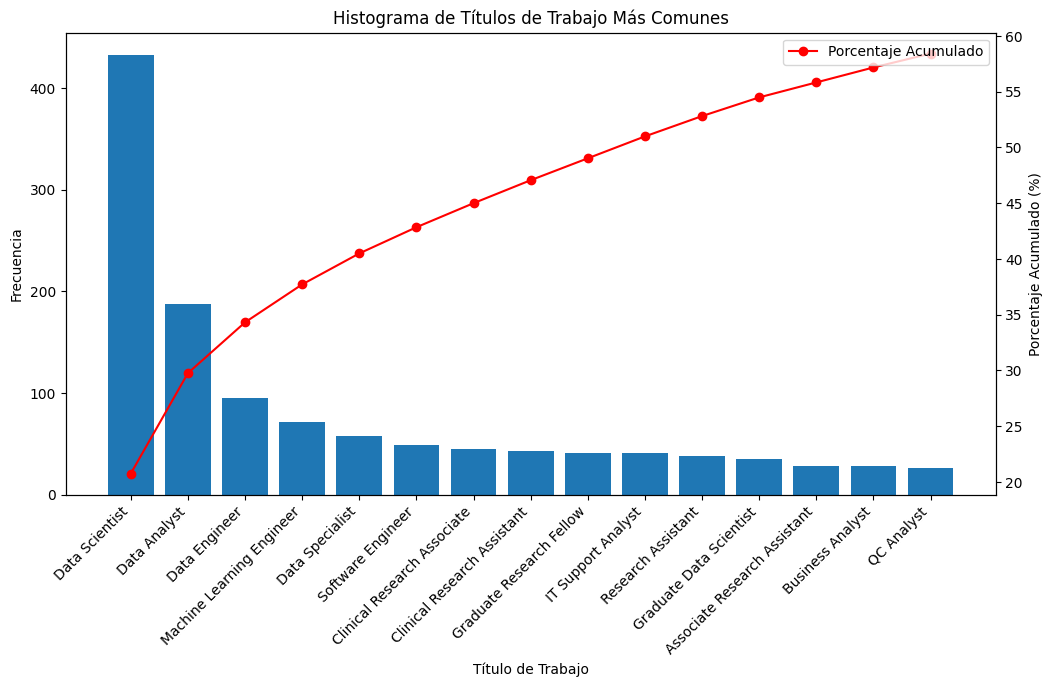

In [ ]:
import matplotlib.pyplot as plt

# Obtén las 15 categorías más comunes
top_15_job_titles = df['Job Title'].value_counts().head(15)

# Calcula el porcentaje acumulado de la frecuencia
percentage_frequency = top_15_job_titles / len(df) * 100
cumulative_percentage = percentage_frequency.cumsum()

# Crea el histograma
plt.figure(figsize=(12, 6))
plt.bar(top_15_job_titles.index, top_15_job_titles)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Título de Trabajo')
plt.ylabel('Frecuencia')
plt.title('Histograma de Títulos de Trabajo Más Comunes')

# Crea el segundo eje y plotea el porcentaje acumulado
ax2 = plt.twinx()
ax2.plot(top_15_job_titles.index, cumulative_percentage, color='red', marker='o', label='Porcentaje Acumulado')
ax2.set_ylabel('Porcentaje Acumulado (%)')
ax2.legend(loc='upper right')

plt.show()

## Por lo que se ve en el grafico, debe ser un databse relacionado bastante con el rubro de la tecnologia
## Se encuentra una mayor frecuencia en relacion al mundo de los datos.


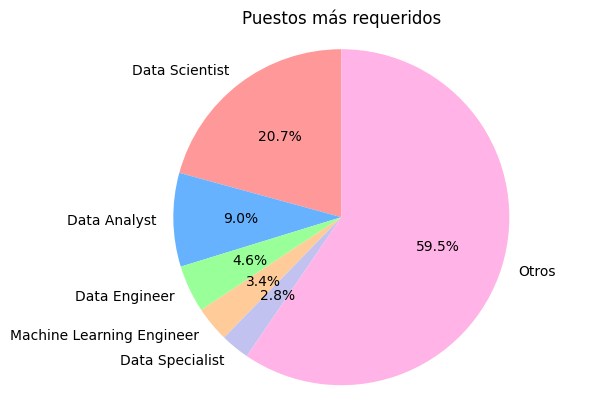

In [ ]:
frecuencia = df["Job Title"].value_counts()
max_porciones = 5
valores_mas_frecuentes = frecuencia.head(max_porciones)
otros_valores = pd.Series(frecuencia.iloc[max_porciones:].sum(), index=['Otros'])
nuevos_valores = pd.concat([valores_mas_frecuentes, otros_valores])
colores_personalizados = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#c2c2f0', '#ffb3e6', '#c2f0c2', '#ffc2b3', '#6666ff', '#c2c2c2', '#c2f0f0']

# Crear el gráfico de pastel con colores personalizados
plt.pie(nuevos_valores, labels=nuevos_valores.index, autopct='%1.1f%%', startangle=90, colors=colores_personalizados)
plt.axis('equal')
plt.title('Puestos más requeridos')

plt.show()

## Hay una gran cantidad de "otros"


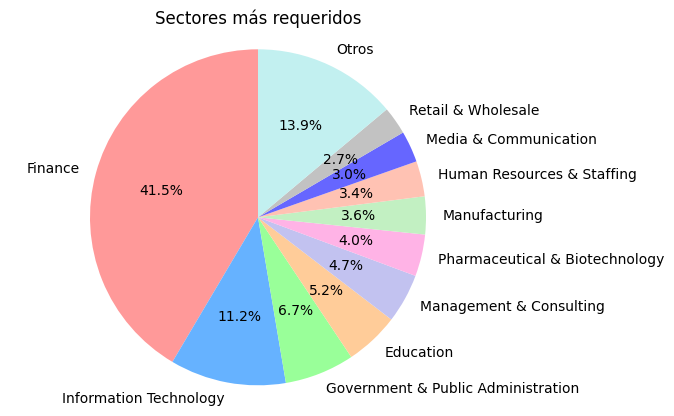

In [ ]:
frecuencia = df['Company Sector'].value_counts()
max_porciones = 10
valores_mas_frecuentes = frecuencia.head(max_porciones)
otros_valores = pd.Series(frecuencia.iloc[max_porciones:].sum(), index=['Otros'])
nuevos_valores = pd.concat([valores_mas_frecuentes, otros_valores])
colores_personalizados = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#c2c2f0', '#ffb3e6', '#c2f0c2', '#ffc2b3', '#6666ff', '#c2c2c2', '#c2f0f0']

# Crear el gráfico de pastel con colores personalizados
plt.pie(nuevos_valores, labels=nuevos_valores.index, autopct='%1.1f%%', startangle=90, colors=colores_personalizados)
plt.axis('equal')
plt.title('Sectores más requeridos')

plt.show()
## Testear si hay diferncias significativas en los salarios de los sectores mas requeridos


In [ ]:
df.rename(columns={'Company Sector': 'Company_Sector'}, inplace=True)

# Realiza un ANOVA
model = ols('High_Estimate ~ C(Company_Sector)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Imprime la tabla ANOVA
print(anova_table)

## En este test podemos ver que la F estadsitica es bastante alta y el valor p es extremadamente bajo, lo que sugiere que almenos una de las categorias  e compnay sector tiene un efecto significativo en el salario.

                         sum_sq      df          F        PR(>F)
C(Company_Sector)  4.783841e+11    23.0  14.893055  8.229436e-54
Residual           2.881140e+12  2063.0        NaN           NaN


<ipython-input-22-355e0eda5f9d>:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


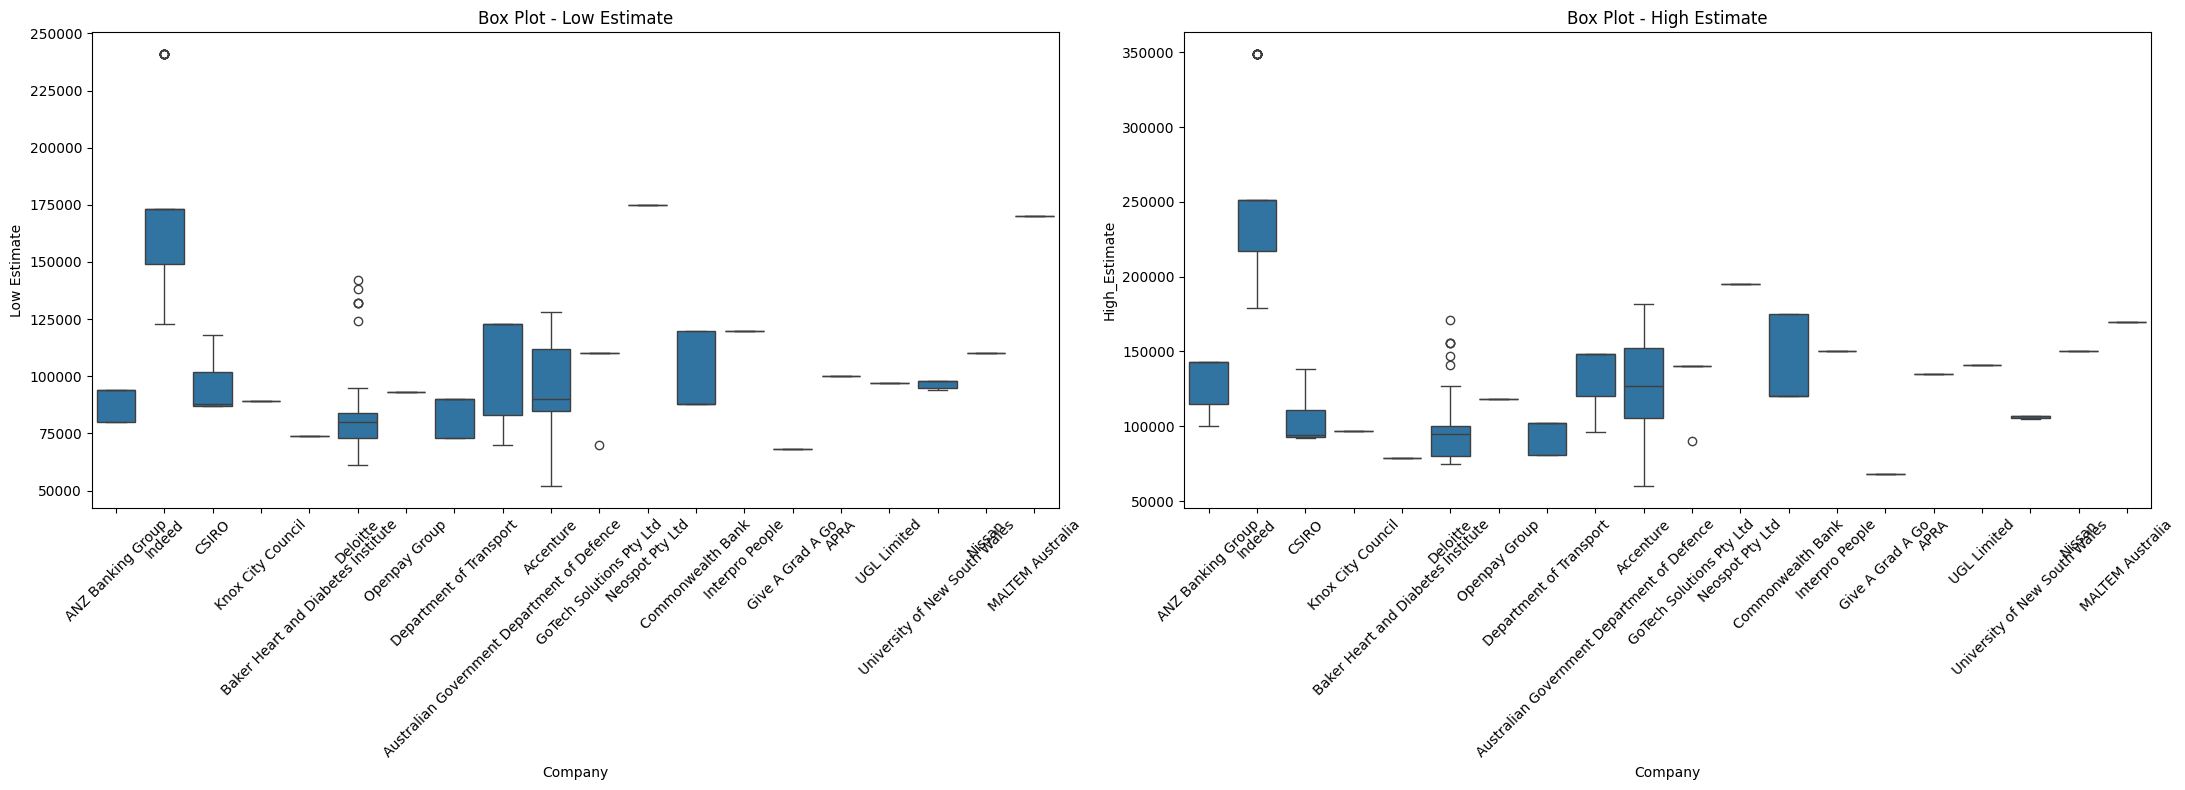

In [ ]:
# Identifica las 7 categorías principales en Company y guárdalas en una lista
top_7_job_titles = df['Company'].value_counts().head(20).index.tolist()

# Filtra el DataFrame para incluir solo las filas con las 7 categorías principales
df_filtered = df[df['Company'].isin(top_7_job_titles)]

# Establece el tamaño de la figura y crea dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Crea un box plot en el primer subgráfico
sns.boxplot(x="Company", y="Low Estimate", data=df_filtered, ax=axes[0])
axes[0].set_title("Box Plot - Low Estimate")

# Crea otro box plot en el segundo subgráfico
sns.boxplot(x="Company", y="High_Estimate", data=df_filtered, ax=axes[1])
axes[1].set_title("Box Plot - High Estimate")

# Rota las etiquetas del eje x en ambos subgráficos
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Ajusta la disposición de los subgráficos
plt.tight_layout()

plt.show()

In [ ]:
# Realiza un ANOVA
model = ols('High_Estimate ~ C(Company)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Imprime la tabla ANOVA
print(anova_table)

## La estadística F es alta, y el valor p es igual a cero, lo que sugiere que al menos una de las categorías de "Company" tiene un efecto significativo en el salario.

                  sum_sq      df          F  PR(>F)
C(Company)  2.927410e+12   322.0  37.113181     0.0
Residual    4.321137e+11  1764.0        NaN     NaN


La empresa Indeed paga salarios mas altos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2087 entries, 0 to 2087
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Job Title                      2087 non-null   object 
 1   Job_location                   2087 non-null   object 
 2   Company                        2087 non-null   object 
 3   Url                            2087 non-null   object 
 4   Estimate Base Salary           2087 non-null   int64  
 5   Low Estimate                   2087 non-null   int64  
 6   High_Estimate                  2087 non-null   int64  
 7   Company_Size                   2087 non-null   object 
 8   Company Type                   2087 non-null   object 
 9   Company_Sector                 2087 non-null   object 
 10  Company Industry               2087 non-null   object 
 11  Job Descriptions               2087 non-null   object 
 12  Company Friend Reccomendation  2087 non-null   f

<ipython-input-25-dc211f84f482>:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


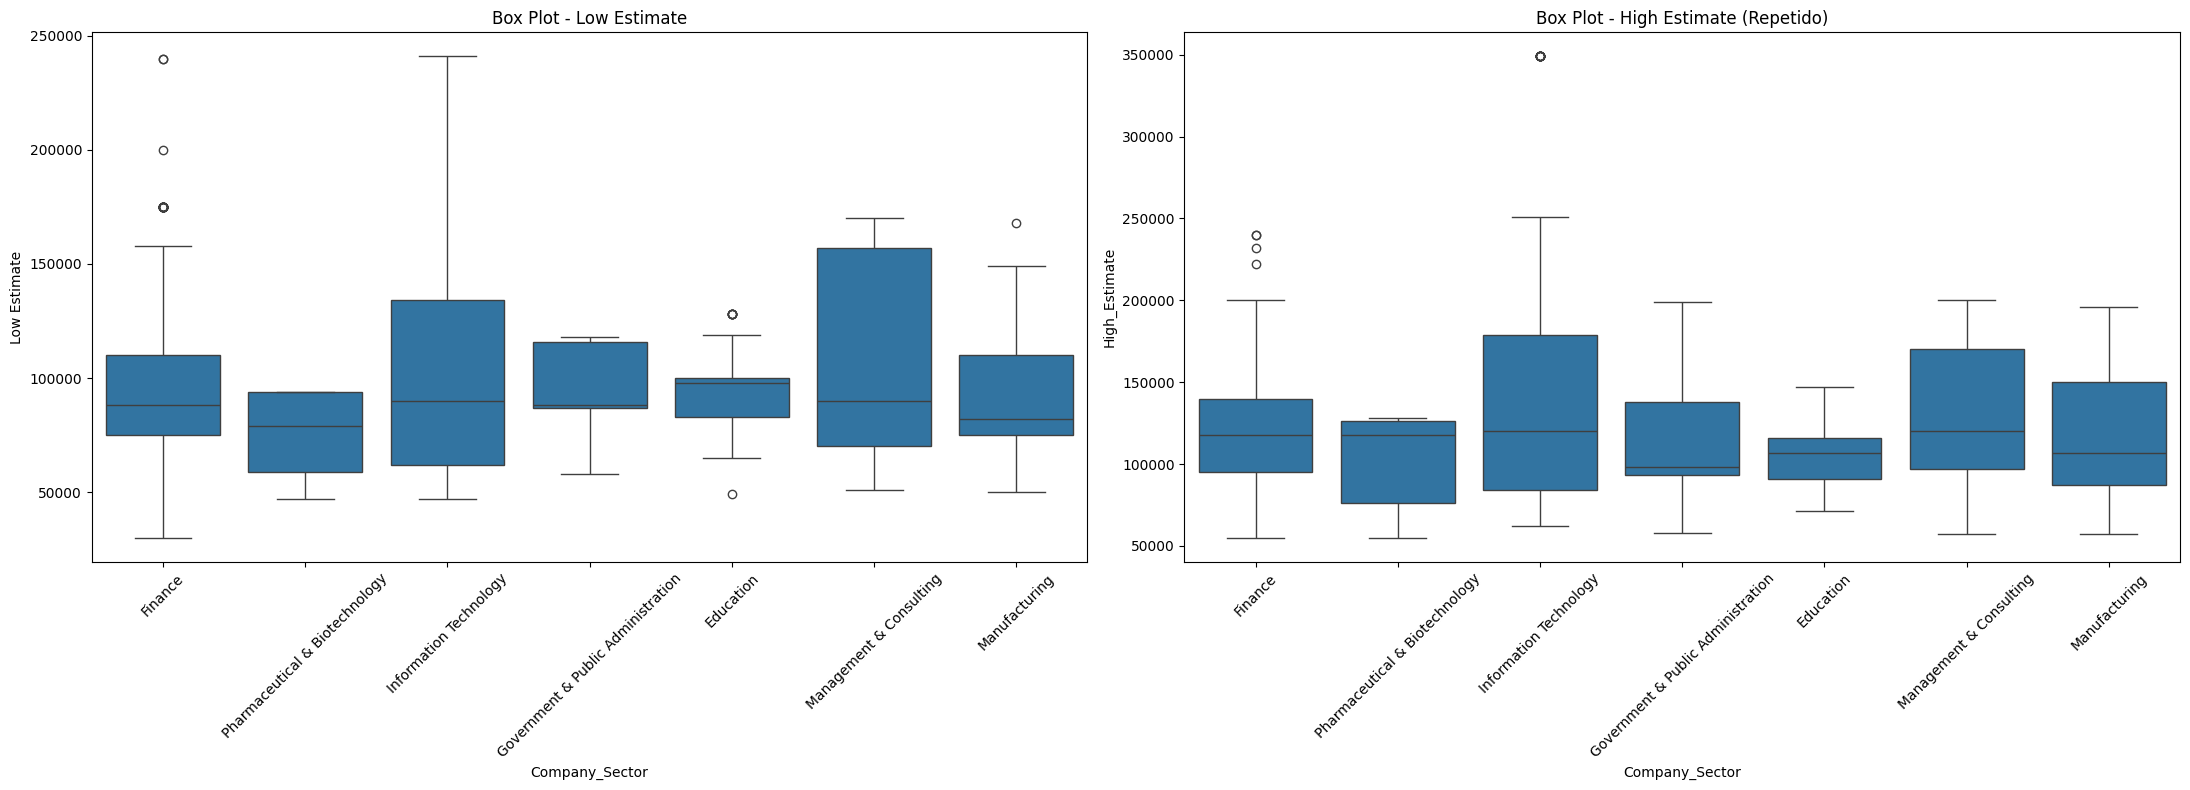

In [ ]:
# Identifica las 7 categorías principales en "Job Title" y guárdalas en una lista
top_7_job_titles = df['Company_Sector'].value_counts().head(7).index.tolist()
# Filtra el DataFrame para incluir solo las filas con las 7 categorías principales
df_filtered = df[df['Company_Sector'].isin(top_7_job_titles)]
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Crea un box plot en el primer subgráfico
sns.boxplot(x="Company_Sector", y="Low Estimate", data=df_filtered, ax=axes[0])
axes[0].set_title("Box Plot - Low Estimate")

# Crea otro box plot en el segundo subgráfico
sns.boxplot(x="Company_Sector", y="High_Estimate", data=df_filtered, ax=axes[1])
axes[1].set_title("Box Plot - High Estimate (Repetido)")

# Rota las etiquetas del eje x en ambos subgráficos
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Ajusta la disposición de los subgráficos
plt.tight_layout()

plt.show()

## Se puede ver que la distribución de los salarios de los puestos de trabajo es bastante similar, exceptuando por la de Software Engenieer

<ipython-input-26-de5414a28231>:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


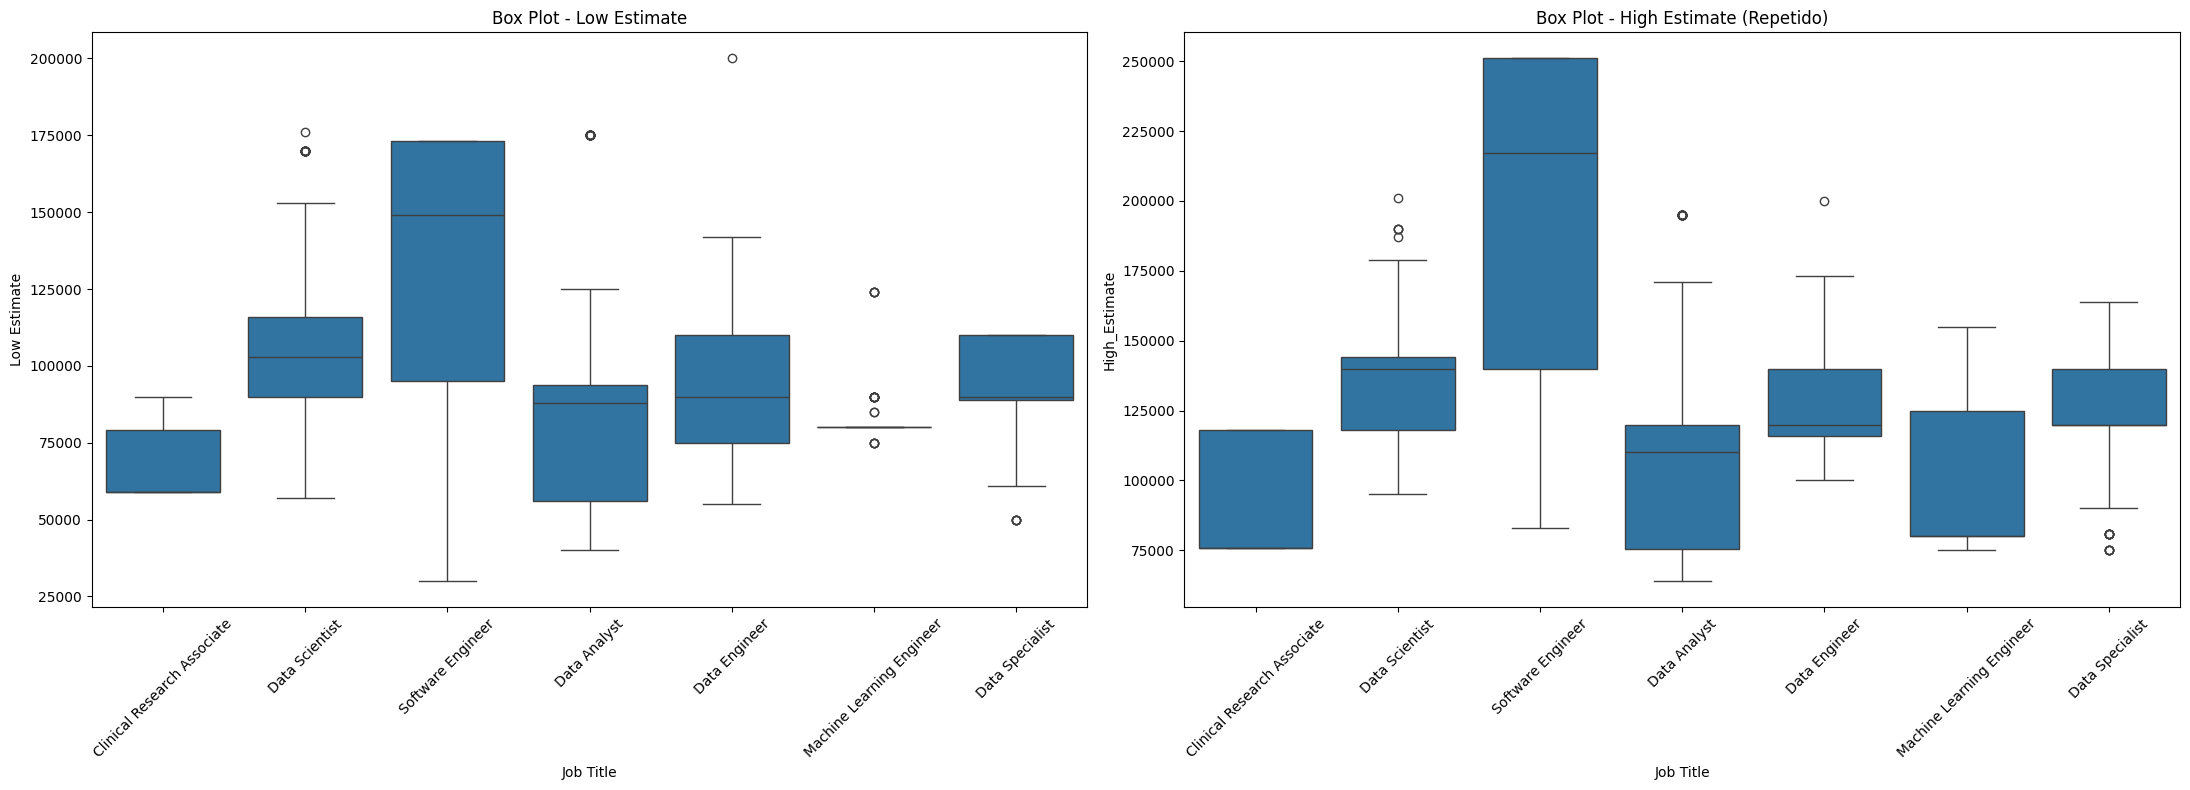

In [ ]:
# Identifica las 7 categorías principales en "Job Title" y guárdalas en una lista
top_7_job_titles = df['Job Title'].value_counts().head(7).index.tolist()
# Filtra el DataFrame para incluir solo las filas con las 7 categorías principales
df_filtered = df[df['Job Title'].isin(top_7_job_titles)]
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Crea un box plot en el primer subgráfico
sns.boxplot(x="Job Title", y="Low Estimate", data=df_filtered, ax=axes[0])
axes[0].set_title("Box Plot - Low Estimate")

# Crea otro box plot en el segundo subgráfico
sns.boxplot(x="Job Title", y="High_Estimate", data=df_filtered, ax=axes[1])
axes[1].set_title("Box Plot - High Estimate (Repetido)")

# Rota las etiquetas del eje x en ambos subgráficos
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Ajusta la disposición de los subgráficos
plt.tight_layout()

plt.show()

## Se puede ver que la distribución de los salarios de los puestos de trabajo es bastante similar, exceptuando por la de Software Engenieer

In [ ]:
df.rename(columns={'Job Title': 'Job_Title'}, inplace=True)
model = ols('High_Estimate ~ C(Job_Title)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

##La estadística F es alta, y el valor p es igual a cero, lo que sugiere que al menos una de las categorías de Job_Title tiene un efecto sginificativo en el salario

                    sum_sq      df          F  PR(>F)
C(Job_Title)  2.349695e+12   245.0  17.484436     0.0
Residual      1.009828e+12  1841.0        NaN     NaN


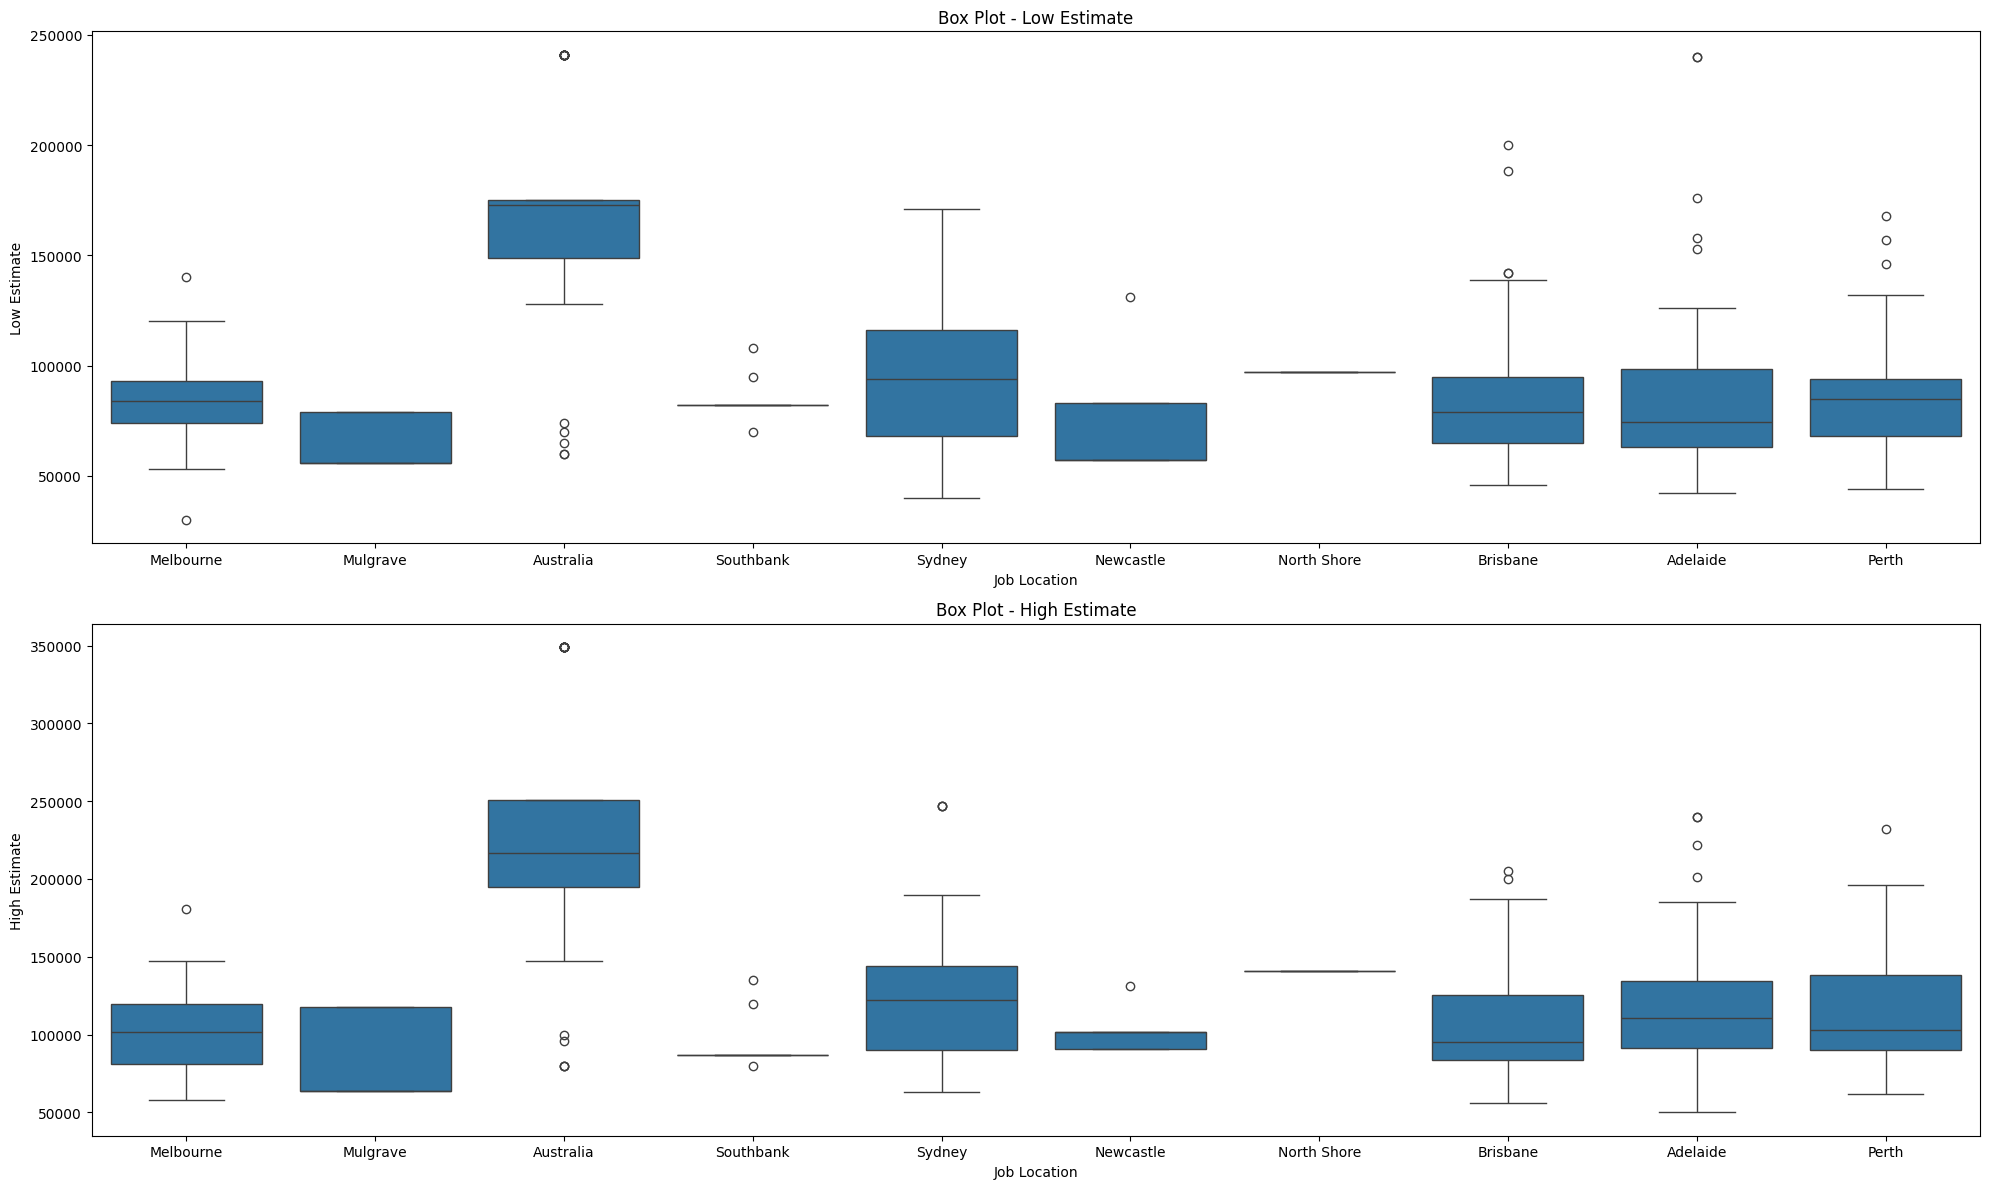

In [ ]:
top_10_job_titles = df['Job_location'].value_counts().head(10).index.tolist()
df_filtered = df[df['Job_location'].isin(top_10_job_titles)]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 12))

# Crear el primer box plot y asignarlo al primer subgráfico (ax1)
sns.boxplot(x="Job_location", y="Low Estimate", data=df_filtered, ax=ax1)
ax1.set_title('Box Plot - Low Estimate')
ax1.set_xlabel('Job Location')
ax1.set_ylabel('Low Estimate')

# Crear el segundo box plot y asignarlo al segundo subgráfico (ax2)
sns.boxplot(x="Job_location", y="High_Estimate", data=df_filtered, ax=ax2)
ax2.set_title('Box Plot - High Estimate')
ax2.set_xlabel('Job Location')
ax2.set_ylabel('High Estimate')

plt.tight_layout()
plt.show()


### Medidas


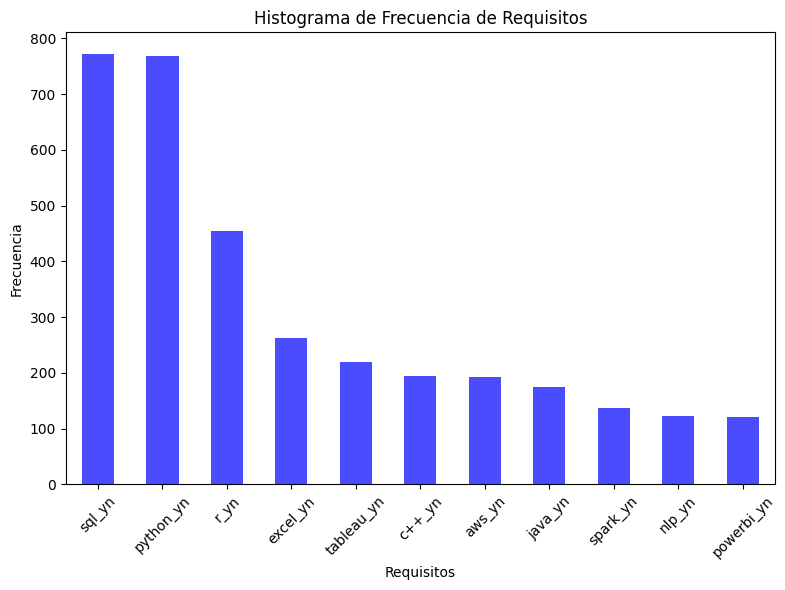

In [ ]:
# ORDENADOS EN FUNCION DE LA CANTIDAD MAS FRECUENTE
columnas_seleccionadas = ['sql_yn', 'python_yn', 'r_yn', 'excel_yn', 'tableau_yn', 'c++_yn', 'aws_yn', 'java_yn', 'spark_yn', 'nlp_yn', 'powerbi_yn']
df[columnas_seleccionadas] = df[columnas_seleccionadas].astype(int)

# Crear un histograma de la frecuencia de requisitos
plt.figure(figsize=(8, 6))
df[columnas_seleccionadas].sum().plot(kind='bar', color='blue', alpha=0.7)

# Configurar etiquetas de ejes y título
plt.xlabel('Requisitos')
plt.ylabel('Frecuencia')
plt.title('Histograma de Frecuencia de Requisitos')

# Mostrar el gráfico
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Los graficos de dispersion, muestran una clara correlacion entre el high low y base estimate.

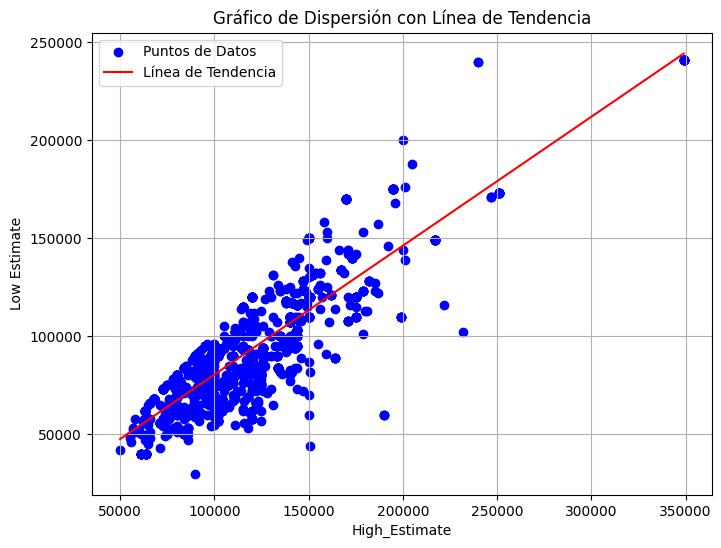

Ecuación de la línea de tendencia: y = 14741.10 + 0.66x
Coeficiente de Correlación (R-squared): 0.76


In [ ]:
from scipy.stats import linregress

# Crear un gráfico de dispersión
plt.figure(figsize=(8, 6))
plt.scatter(df["High_Estimate"], df['Low Estimate'], c='blue', label='Puntos de Datos')

# Ajustar una regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(df["High_Estimate"], df['Low Estimate'])

# Crear una línea de tendencia
tendencia_x = np.array([min(df["High_Estimate"]), max(df["High_Estimate"])])
tendencia_y = intercept + slope * tendencia_x
plt.plot(tendencia_x, tendencia_y, c='red', label='Línea de Tendencia')

# Etiquetas de ejes y título
plt.xlabel("High_Estimate")
plt.ylabel('Low Estimate')
plt.title('Gráfico de Dispersión con Línea de Tendencia')

plt.legend()
plt.grid(True)
plt.show()
# Mostrar la ecuación de la línea de tendencia y el coeficiente de correlación
print(f"Ecuación de la línea de tendencia: y = {intercept:.2f} + {slope:.2f}x")
print(f"Coeficiente de Correlación (R-squared): {r_value**2:.2f}")


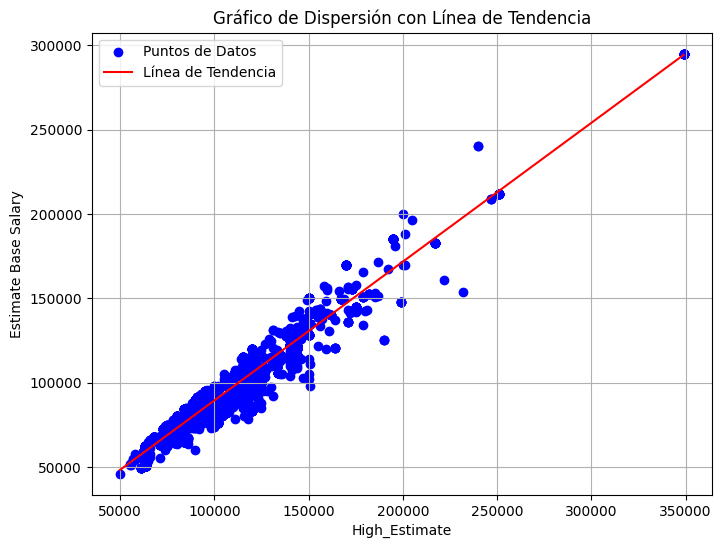

Ecuación de la línea de tendencia: y = 7216.16 + 0.82x
Coeficiente de Correlación (R-squared): 0.94


In [ ]:
# Crear un gráfico de dispersión
plt.figure(figsize=(8, 6))
plt.scatter(df["High_Estimate"], df['Estimate Base Salary'], c='blue', label='Puntos de Datos')

# Ajustar una regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(df["High_Estimate"], df['Estimate Base Salary'])

# Crear una línea de tendencia
tendencia_x = np.array([min(df["High_Estimate"]), max(df["High_Estimate"])])
tendencia_y = intercept + slope * tendencia_x
plt.plot(tendencia_x, tendencia_y, c='red', label='Línea de Tendencia')

# Etiquetas de ejes y título
plt.xlabel("High_Estimate")
plt.ylabel('Estimate Base Salary')
plt.title('Gráfico de Dispersión con Línea de Tendencia')

plt.legend()
plt.grid(True)
plt.show()
# Mostrar la ecuación de la línea de tendencia y el coeficiente de correlación
print(f"Ecuación de la línea de tendencia: y = {intercept:.2f} + {slope:.2f}x")
print(f"Coeficiente de Correlación (R-squared): {r_value**2:.2f}")

In [ ]:
## Pareciera que el grafico tiene una distribucion tirando a una normal, a ver que dicen las medidas estadisticas

In [ ]:
df.describe()


,Estimate Base Salary,Low Estimate,High_Estimate,Company Friend Reccomendation,Company Career Opportinities,Compensation and Benefits,Company Culture and Values,Company Senior Management,Company Work Life Balance,python_yn,r_yn,sql_yn,java_yn,c++_yn,spark_yn,excel_yn,aws_yn,tableau_yn,powerbi_yn,nlp_yn
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,102784.225683,91081.456636,116193.579300,76.834691,3.689698,3.606037,3.867657,3.469046,3.790273,0.367992,0.217537,0.369909,0.083852,0.092956,0.065644,0.126018,0.092477,0.105414,0.057978,0.058457
std,34047.212088,30271.099726,40131.159569,13.808649,0.525664,0.506025,0.527129,0.529431,0.541018,0.482375,0.412670,0.482895,0.277233,0.290441,0.247719,0.331949,0.289768,0.307160,0.233758,0.234662
min,46133.000000,30000.000000,50000.000000,15.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,80000.000000,70000.000000,87000.000000,71.000000,3.400000,3.400000,3.600000,3.200000,3.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,96021.000000,85000.000000,111000.000000,79.000000,3.700000,3.600000,3.900000,3.500000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,120000.000000,106500.000000,140000.000000,85.000000,4.000000,3.800000,4.100000,3.700000,4.100000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,295000.000000,241000.000000,349000.000000,100.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df["High_Estimate"].mode()

## Si bien no son iguales, la media moda y meidana estan muy cercanas, menos de un 10% de diferencia.


0    120000
Name: High_Estimate, dtype: int64

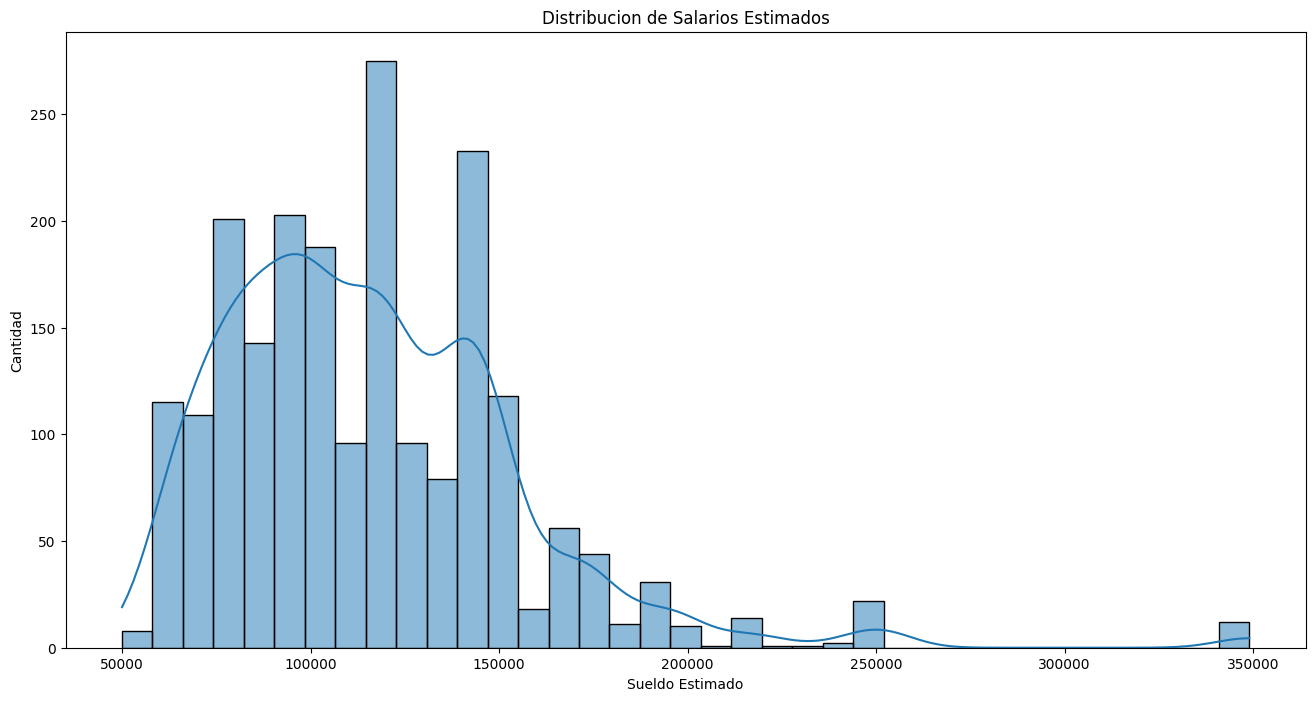

In [ ]:
# Crear un gráfico de distribución (histograma y KDE)

plt.figure(figsize=(16, 8))

sns.histplot(data= df, x="High_Estimate", kde=True)

plt.xlabel('Sueldo Estimado')
plt.ylabel('Cantidad')
plt.title('Distribucion de Salarios Estimados')

plt.show()

In [ ]:
## Por lo visto en los graficos de boxplot exceptuando el software engineer, el resto tienen una mediana bastante parecida y los rangos se encuentran bastante similares.

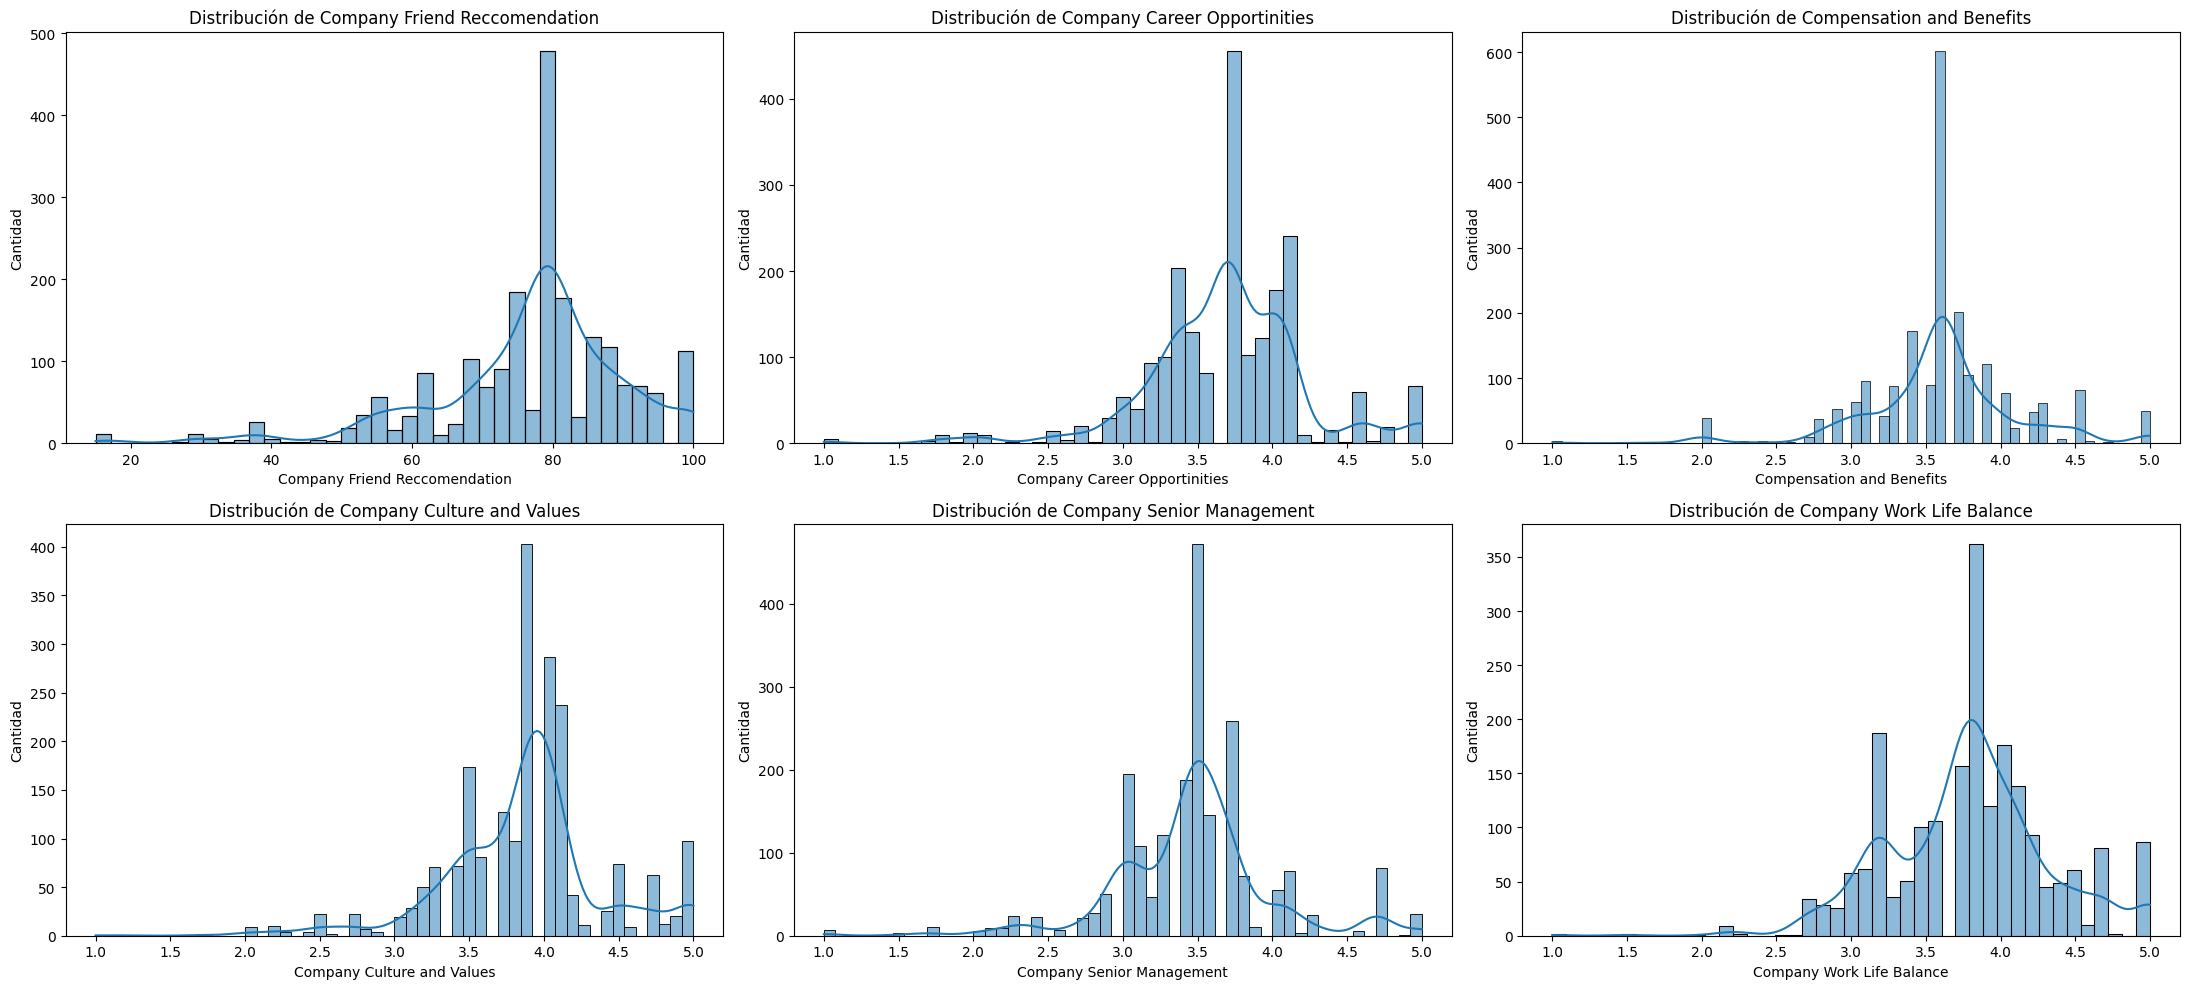

In [ ]:
# Variables que deseas visualizar
variables = [ 'Company Friend Reccomendation',
       'Company Career Opportinities', 'Compensation and Benefits',
       'Company Culture and Values', 'Company Senior Management',
       'Company Work Life Balance']

# Establece el tamaño de la figura
plt.figure(figsize=(22, 10))

# Itera a través de las variables para crear múltiples gráficos
for i, variable in enumerate(variables, 1):
    plt.subplot(2, 3, i)  # 2 filas, 3 columnas, posición actual
    sns.histplot(data=df, x=variable, kde=True)
    plt.xlabel(variable)
    plt.ylabel('Cantidad')
    plt.title(f'Distribución de {variable}')

# Ajusta el espaciado entre los gráficos
plt.tight_layout()

# Muestra los gráficos
plt.show()


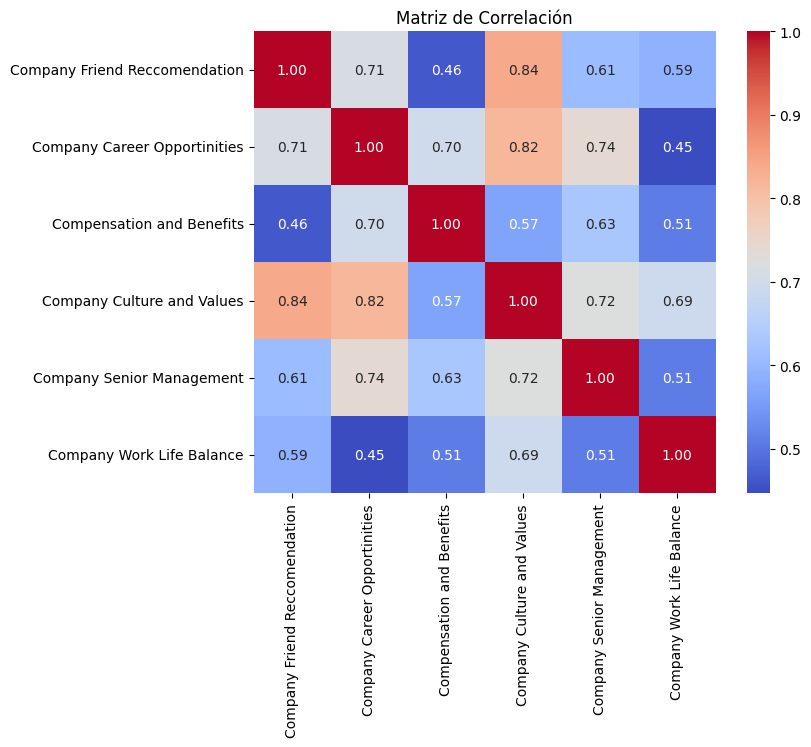

In [ ]:
# Selecciona las variables de interés
variables = [ 'Company Friend Reccomendation',
       'Company Career Opportinities', 'Compensation and Benefits',
       'Company Culture and Values', 'Company Senior Management',
       'Company Work Life Balance']
# Crea una subconjunto de datos con las variables seleccionadas
subset_df = df[variables]
# Calcula la matriz de correlación
correlation_matrix = subset_df.corr()
# Establece el tamaño de la figura
plt.figure(figsize=(8, 6))
# Crea un mapa de calor para visualizar la matriz de correlación
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
# Etiquetas con saltos de línea
labels = ['Company Culture\nand Values', 'Company Senior\nManagement', 'Company Career\nOpportunities', 'Company Friend\nRecommendation', 'Company Work Life\nBalance', 'Compensation\nand Benefits']
plt.title('Matriz de Correlación')
# Muestra la matriz de correlación
plt.show()


Dentro de las varaiables relacionadas con el "rating" de la empresa, no se ve que tengan una gran correlacion, excpecto cultura y valores co oportunidades de carrera

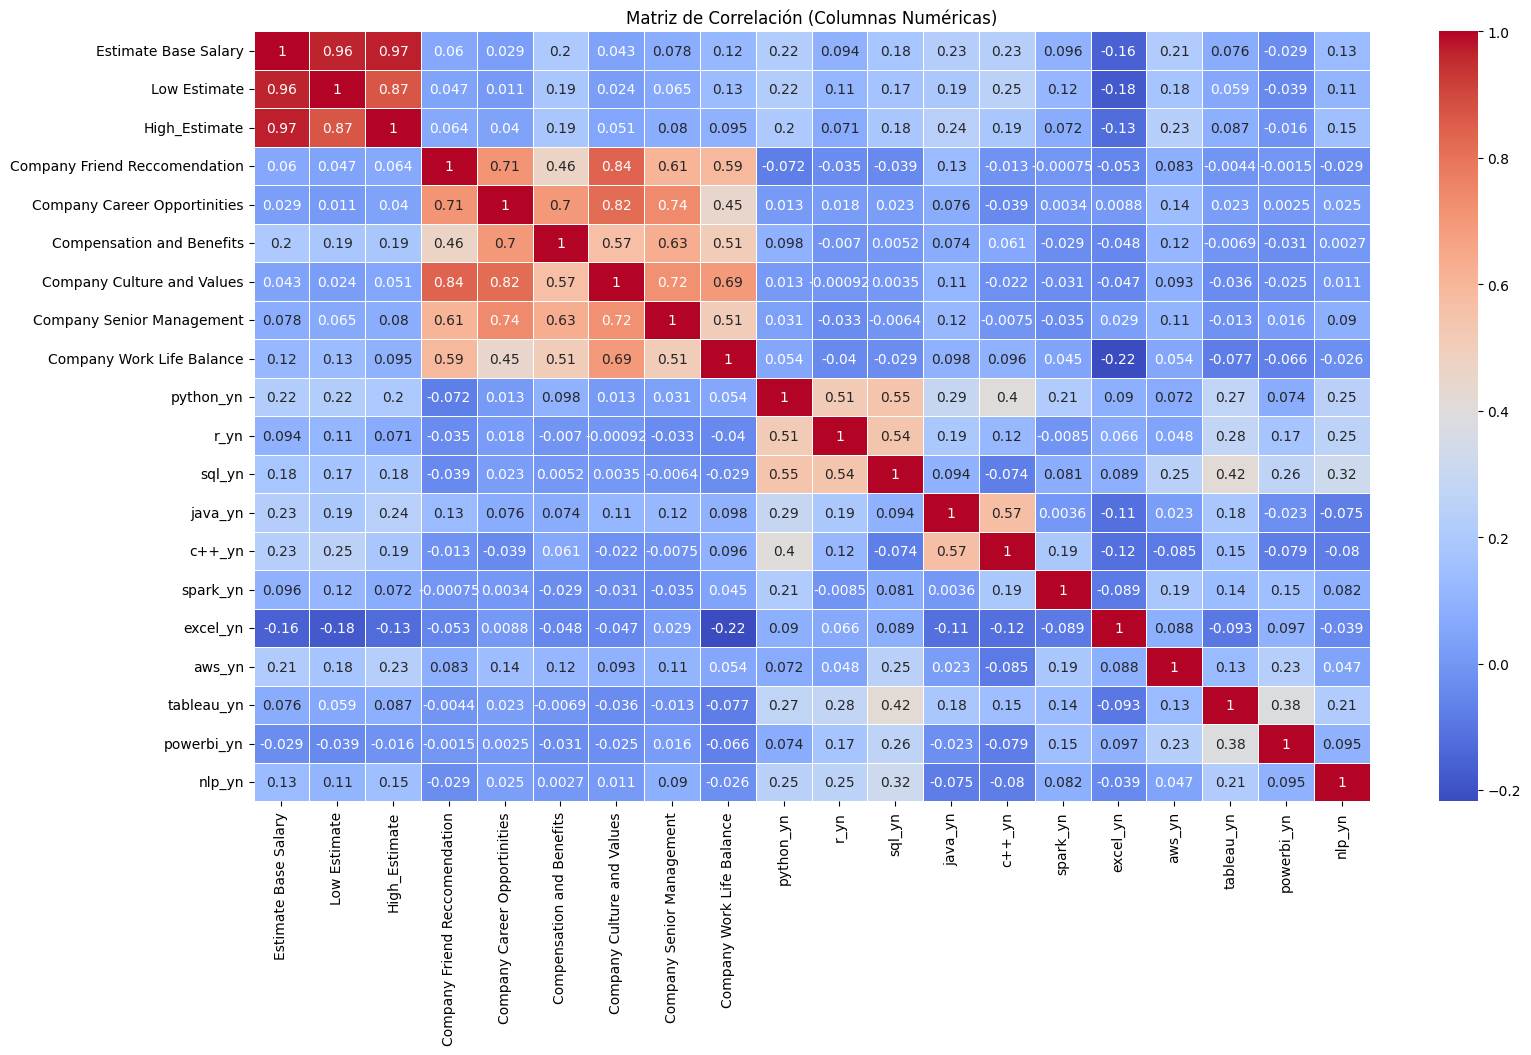

In [ ]:
# Filtrar solo las columnas numéricas
numeric_columns = df.select_dtypes(include=['number'])

# Calcular la matriz de correlación para las columnas numéricas
correlation_matrix = numeric_columns.corr()

# Crear un heatmap
plt.figure(figsize=(18, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Matriz de Correlación (Columnas Numéricas)')
plt.show()

En la matriz de correlacion se pueden ver varios grupos de variables que estan correlacionadas.
Dentro de esto podemos encontrar las relacionadas con el salario (muy fuerte): low / high / Estimate Base.
Se puede ver una relacion un poco menos fuerte en las variables que hacen referncia al rating de la empresa.
En cuanto a los requerimientos se puede notar grupos correlacionados como (python, sql y r), (java y c++), (powerbi y tableau)

## **5. Seleccion de Variables**

#### FEATURE SELECTION

Despues de analizar tanto el high estimate como el Estimate Base Salary, utilizando los 3 forma de Feature selection, pude concluir que las variables mas relevante para explicar el salario son:

*   Categoricas: Job Title, Company Size, Company Type
*   Medidas: Company Friend Reccomendation, java_yn, tensorflow_yn,

##### High Estimate

In [ ]:
# Copiar el DataFrame original
df_copia = df.copy()

# Verificar que se haya copiado y renombrado correctamente
df_copia.head()


,Job_Title,Job_location,Company,Url,Estimate Base Salary,Low Estimate,High_Estimate,Company_Size,Company Type,Company_Sector,...,cassandra_yn,hive_yn,bigml_yn,tableau_yn,powerbi_yn,nlp_yn,pytorch_yn,tensorflow_yn,mathematic_yn,statistic_yn
0,Analyst,Melbourne,ANZ Banking Group,https://www.glassdoor.com.au/partner/jobListin...,95917,80000,115000,10000+ Employees,Company - Public,Finance,...,False,False,False,0,0,0,False,False,True,False
1,Clinical Research Associate,Mulgrave,Bristol Myers Squibb,https://www.glassdoor.com.au/partner/jobListin...,96555,79000,118000,10000+ Employees,Company - Public,Pharmaceutical & Biotechnology,...,False,False,False,0,0,0,False,False,False,False
2,Clinical Research Associate,Mulgrave,Bristol Myers Squibb,https://www.glassdoor.com.au/partner/jobListin...,96555,79000,118000,10000+ Employees,Company - Public,Pharmaceutical & Biotechnology,...,False,False,False,0,0,0,False,False,False,False
3,Clinical Research Associate,Mulgrave,Bristol Myers Squibb,https://www.glassdoor.com.au/partner/jobListin...,96555,79000,118000,10000+ Employees,Company - Public,Pharmaceutical & Biotechnology,...,False,False,False,0,0,0,False,False,False,False
4,Data Scientist,Melbourne,ANZ Banking Group,https://www.glassdoor.com.au/partner/jobListin...,115631,94000,143000,10000+ Employees,Company - Public,Finance,...,False,False,False,0,0,0,False,False,False,False


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from collections import Counter
from sklearn.model_selection import KFold


# Identifica las columnas de tipo 'object'.
categorical_columns = df_copia.select_dtypes(include=['object']).columns

# Crea una instancia de LabelEncoder
label_encoder = LabelEncoder()

# Aplica Label Encoding a todas las columnas categóricas.
for column in categorical_columns:
    df_copia[column] = label_encoder.fit_transform(df_copia[column])

# Define las variables independientes (X) y la variable objetivo (y).
X = df_copia.drop(columns=['High_Estimate'])  # Excluye la variable objetivo
y = df_copia['High_Estimate']

# Crea una instancia del modelo de regresión lineal.
model = LinearRegression()

# Crea una instancia de SequentialFeatureSelector (SFS).
sfs = SequentialFeatureSelector(model, k_features=10 , forward=True, floating=False, scoring='r2', cv=5)

# Ajusta SFS al conjunto de datos.
sfs.fit(X, y)

# Obtiene las características seleccionadas.
selected_features = X.columns[list(sfs.k_feature_idx_)]

# Usamos 'selected_features' para seleccionar las características relevantes en tu modelo de regresión lineal.


In [ ]:
# Identifica las columnas de tipo 'object'.
categorical_columns = df_copia.select_dtypes(include=['object']).columns

# Crea una instancia de LabelEncoder
label_encoder = LabelEncoder()

# Aplica Label Encoding a todas las columnas categóricas.
for column in categorical_columns:
    df_copia[column] = label_encoder.fit_transform(df_copia[column])

# Define las variables independientes (X) y la variable objetivo (y).
X = df_copia.drop(columns=['High_Estimate'])  # Excluye la variable objetivo
y = df_copia['High_Estimate']

# Crear una instancia del modelo de regresión lineal.
model = LinearRegression()

# Definir el número de divisiones para la validación cruzada
n_splits = 5  # Puedes ajustar este número según tus necesidades

# Crear una instancia de SequentialFeatureSelector (SFS).
sfs = SequentialFeatureSelector(model, k_features=10, forward=True, floating=False, scoring='r2')

# Inicializar K-Fold Cross-Validation
kf = KFold(n_splits=n_splits)

# Lista para almacenar las características seleccionadas en cada iteración
selected_features_list = []

# Realizar la selección cruzada
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Ajustar SFS al conjunto de entrenamiento
    sfs.fit(X_train, y_train)

    # Obtener las características seleccionadas en esta iteración
    selected_features = X.columns[list(sfs.k_feature_idx_)]
    selected_features_list.append(selected_features)

# Calcular las características seleccionadas más comunes en todas las iteraciones
all_selected_features = [feature for sublist in selected_features_list for feature in sublist]
feature_counts = Counter(all_selected_features)
most_common_features = feature_counts.most_common(10)  # Aquí, se seleccionan las 10 características más comunes

selected_featuresc = [feature for feature, _ in most_common_features]

# Usar 'selected_featuresc' para seleccionar las características relevantes en tu modelo de regresión lineal.



In [ ]:
# Identifica las columnas de tipo 'object'.
categorical_columns = df_copia.select_dtypes(include=['object']).columns

# Crea una instancia de LabelEncoder
label_encoder = LabelEncoder()

# Aplica Label Encoding a todas las columnas categóricas.
for column in categorical_columns:
    df_copia[column] = label_encoder.fit_transform(df_copia[column])

# Define las variables independientes (X) y la variable objetivo (y).
X = df_copia.drop(columns=['High_Estimate'])  # Excluye la variable objetivo
y = df_copia['High_Estimate']

# Crea una instancia del modelo de regresión lineal.
model = LinearRegression()

# Crea una instancia de SequentialFeatureSelector (SFS).
sfs = SequentialFeatureSelector(model, k_features=10 , forward=False, floating=False, scoring='r2', cv=5)

# Ajusta SFS al conjunto de datos.
sfs.fit(X, y)

# Obtiene las características seleccionadas.
selected_featuresb = X.columns[list(sfs.k_feature_idx_)]

# Usamos 'selected_features' para seleccionar las características relevantes en tu modelo de regresión lineal.

In [ ]:
selected_features

Index(['Job_Title', 'Estimate Base Salary', 'Low Estimate', 'Company_Size',
       'Company Type', 'State', 'java_yn', 'sas_yn', 'tensorflow_yn',
       'mathematic_yn'],
      dtype='object')

In [ ]:
selected_featuresc

['Job_Title',
 'Estimate Base Salary',
 'Low Estimate',
 'Company_Size',
 'java_yn',
 'mathematic_yn',
 'tensorflow_yn',
 'nosql_yn',
 'sas_yn',
 'Company_Sector']

In [ ]:
selected_featuresb

Index(['Job_Title', 'Estimate Base Salary', 'Low Estimate', 'Company_Size',
       'Company Type', 'Company Friend Reccomendation', 'java_yn', 'nosql_yn',
       'tensorflow_yn', 'mathematic_yn'],
      dtype='object')

##### Estimate Base Salary

In [ ]:
# Identifica las columnas de tipo 'object'.
categorical_columns = df_copia.select_dtypes(include=['object']).columns

# Crea una instancia de LabelEncoder
label_encoder = LabelEncoder()

# Aplica Label Encoding a todas las columnas categóricas.
for column in categorical_columns:
    df_copia[column] = label_encoder.fit_transform(df_copia[column])

# Define las variables independientes (X) y la variable objetivo (y).
X = df_copia.drop(columns=['Estimate Base Salary'])  # Excluye la variable objetivo
y = df_copia['Estimate Base Salary']

# Crea una instancia del modelo de regresión lineal.
model = LinearRegression()

# Crea una instancia de SequentialFeatureSelector (SFS).
sfs = SequentialFeatureSelector(model, k_features=10 , forward=True, floating=False, scoring='r2', cv=5)

# Ajusta SFS al conjunto de datos.
sfs.fit(X, y)

# Obtiene las características seleccionadas.
selected_featuresEBSF = X.columns[list(sfs.k_feature_idx_)]

# Usamos 'selected_features' para seleccionar las características relevantes en tu modelo de regresión lineal.

In [ ]:
# Identifica las columnas de tipo 'object'.
categorical_columns = df_copia.select_dtypes(include=['object']).columns

# Crea una instancia de LabelEncoder
label_encoder = LabelEncoder()

# Aplica Label Encoding a todas las columnas categóricas.
for column in categorical_columns:
    df_copia[column] = label_encoder.fit_transform(df_copia[column])

# Define las variables independientes (X) y la variable objetivo (y).
X = df_copia.drop(columns=['Estimate Base Salary'])  # Excluye la variable objetivo
y = df_copia['Estimate Base Salary']

# Crea una instancia del modelo de regresión lineal.
model = LinearRegression()

# Crea una instancia de SequentialFeatureSelector (SFS).
sfs = SequentialFeatureSelector(model, k_features=10 , forward=False, floating=False, scoring='r2', cv=5)

# Ajusta SFS al conjunto de datos.
sfs.fit(X, y)

# Obtiene las características seleccionadas.
selected_featuresEBSB = X.columns[list(sfs.k_feature_idx_)]

# Usamos 'selected_features' para seleccionar las características relevantes en tu modelo de regresión lineal.

In [ ]:
# Identifica las columnas de tipo 'object'.
categorical_columns = df_copia.select_dtypes(include=['object']).columns

# Crea una instancia de LabelEncoder
label_encoder = LabelEncoder()

# Aplica Label Encoding a todas las columnas categóricas.
for column in categorical_columns:
    df_copia[column] = label_encoder.fit_transform(df_copia[column])

# Define las variables independientes (X) y la variable objetivo (y).
X = df_copia.drop(columns=['Estimate Base Salary'])  # Excluye la variable objetivo
y = df_copia['Estimate Base Salary']

# Crear una instancia del modelo de regresión lineal.
model = LinearRegression()

# Definir el número de divisiones para la validación cruzada
n_splits = 5  # Puedes ajustar este número según tus necesidades

# Crear una instancia de SequentialFeatureSelector (SFS).
sfs = SequentialFeatureSelector(model, k_features=10, forward=True, floating=False, scoring='r2')

# Inicializar K-Fold Cross-Validation
kf = KFold(n_splits=n_splits)

# Lista para almacenar las características seleccionadas en cada iteración
selected_features_list = []

# Realizar la selección cruzada
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Ajustar SFS al conjunto de entrenamiento
    sfs.fit(X_train, y_train)

    # Obtener las características seleccionadas en esta iteración
    selected_features = X.columns[list(sfs.k_feature_idx_)]
    selected_features_list.append(selected_features)

# Calcular las características seleccionadas más comunes en todas las iteraciones
all_selected_features = [feature for sublist in selected_features_list for feature in sublist]
feature_counts = Counter(all_selected_features)
most_common_features = feature_counts.most_common(10)  # Aquí, se seleccionan las 10 características más comunes

selected_featuresEBSC = [feature for feature, _ in most_common_features]

# Usar 'selected_featuresc' para seleccionar las características relevantes en tu modelo de regresión lineal.

In [ ]:
selected_featuresEBSF

Index(['Job_Title', 'Low Estimate', 'High_Estimate', 'Company_Size',
       'Company Type', 'Company Friend Reccomendation', 'java_yn', 'matlab_yn',
       'tensorflow_yn', 'mathematic_yn'],
      dtype='object')

In [ ]:
selected_featuresEBSB

Index(['Job_Title', 'Low Estimate', 'High_Estimate', 'Company_Size',
       'Company Type', 'Company Friend Reccomendation', 'java_yn', 'matlab_yn',
       'tensorflow_yn', 'mathematic_yn'],
      dtype='object')

In [ ]:
selected_featuresEBSC

['Low Estimate',
 'High_Estimate',
 'Company_Size',
 'java_yn',
 'mathematic_yn',
 'Company Type',
 'scala_yn',
 'Job_Title',
 'matlab_yn',
 'nosql_yn']

#### pca

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


In [ ]:
# Definir las columnas categóricas antes de utilizarlas

categorical_cols = ["Company_Size", "java_yn", "mathematic_yn", "Company Type", "scala_yn", "Job_Title", "matlab_yn", "nosql_yn"] # Aquí debes especificar las columnas categóricas de tu conjunto de datos

# Manejar variables categóricas con codificación one-hot

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

In [ ]:
# Definir las columnas categóricas antes de utilizarlas

numeric_cols = ["Low Estimate", "High_Estimate"] # Aquí debes especificar las columnas categóricas de tu conjunto de datos

# Manejar variables categóricas con codificación one-hot

X_train_encoded = pd.get_dummies(X_train, columns=numeric_cols, drop_first=True)

X_test_encoded = pd.get_dummies(X_test, columns=numeric_cols, drop_first=True)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Suponiendo que 'X_train' y 'X_test' son DataFrames con tus datos de entrenamiento y prueba

# Manejar variables categóricas con codificación one-hot
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Asegurarse de que las columnas en ambos conjuntos de datos coincidan
common_columns = list(set(X_train_encoded.columns) & set(X_test_encoded.columns))

# Agregar columnas faltantes en ambos conjuntos de datos
missing_columns_train = list(set(X_test_encoded.columns) - set(X_train_encoded.columns))
missing_columns_test = list(set(X_train_encoded.columns) - set(X_test_encoded.columns))

X_train_encoded = pd.concat([X_train_encoded, pd.DataFrame(0, index=X_train_encoded.index, columns=missing_columns_test)], axis=1)
X_test_encoded = pd.concat([X_test_encoded, pd.DataFrame(0, index=X_test_encoded.index, columns=missing_columns_train)], axis=1)

# Asegurarse de que las columnas estén en el mismo orden
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Estandarización de las variables numéricas
scaler = StandardScaler()
X_train_encoded[numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_encoded[numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

# Aplicar PCA
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_encoded)

# Aplicar la misma transformación a los datos de prueba
X_test_pca = pca.transform(X_test_encoded)


In [ ]:
# Visualizar varianza explicada por cada componente principal
print("Varianza Explicada por cada Componente Principal:")
print(pca.explained_variance_ratio_)

# Visualizar varianza acumulativa
print("\nVarianza Acumulativa:")
print(pca.explained_variance_ratio_.cumsum())

# Visualizar los dos primeros componentes principales
print("\nComponentes Principales:")
print(pca.components_)

# Transformar los datos originales
X_train_pca = pca.transform(X_train_encoded)


Varianza Explicada por cada Componente Principal:
[0.9105108  0.06878145 0.01809649 0.00131311]

Varianza Acumulativa:
[0.9105108  0.97929225 0.99738874 0.99870185]

Componentes Principales:
[[-2.21862894e-06  7.57824714e-06  7.60295024e-07 -1.85955689e-05
   3.00544193e-06 -2.40955355e-05 -1.52339216e-07  7.68799844e-07
  -8.55369523e-06 -5.79610707e-06 -1.31021555e-05 -3.26952093e-06
  -5.17728220e-06 -1.66080118e-05  1.90604136e-06 -0.00000000e+00
  -3.14046771e-06 -1.34170817e-06 -1.38576585e-05 -9.44643801e-07
  -1.05220753e-05  1.09686478e-05  2.52165710e-05  3.27866469e-06
   2.41618205e-06  1.41621901e-06  1.02280609e-06 -0.00000000e+00
  -1.70003050e-05 -9.77317578e-06  1.53258328e-06 -4.63251111e-05
   1.44380780e-06  2.00708981e-06 -6.62923891e-06 -3.85574023e-06
   1.21812388e-05  7.56149887e-06  1.89552614e-06  6.29762521e-06
   1.40736299e-06  1.09057446e-06 -7.55102198e-06 -5.37886899e-04
  -9.07632384e-07 -4.30490902e-06  9.99944309e-01 -5.79675615e-07
   9.75237934e-06

## **6.Modelamiento**

#### Instalacion

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import statsmodels.api as sm


*   Categoricas: Job Title, Company Size, Company Type
*   Medidas: Company Friend Reccomendation, java_yn, tensorflow_yn,

In [ ]:
trabajo_de_interes = "Data Engineer"
empresa_de_interes = "51 to 200 Employees"
empresa_de_interes2 = "Indeed"

# Crear un modelo de regresión lineal que incluye las tres variables independientes
model = 'High_Estimate ~ Job_Title + Company_Size + Company'
lm = sm.OLS.from_formula(formula=model, data=df).fit()

# Realizar la predicción para los casos de interés
data_prediccion = pd.DataFrame({"Job_Title": trabajo_de_interes, "Company_Size": empresa_de_interes, "Company": empresa_de_interes2}, index=[0])
prediccion = lm.predict(data_prediccion)

resultado_formateado = '${:,.0f}'.format(prediccion.iloc[0])
print(f"Predicción de salario para {trabajo_de_interes}, {empresa_de_interes}, {empresa_de_interes2}:{resultado_formateado}")


Predicción de salario para Data Engineer, 51 to 200 Employees, Indeed:$276,108


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd

# Suponiendo que 'df' es tu DataFrame original y 'X_train_encoded' contiene las variables transformadas por PCA

# Manejar variables categóricas con codificación one-hot
X_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Estandarizar las variables numéricas
scaler = StandardScaler()
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

# Aplicar PCA
pca = PCA(n_components=2)  # Ajusta el número de componentes según tus necesidades
X_pca = pca.fit_transform(X_encoded)

# Ajustar un modelo de regresión lineal utilizando las componentes principales
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_pca_df['High_Estimate'] = df['High_Estimate']  # Añadir la variable objetivo

model_pca = 'High_Estimate ~ PC1 + PC2'
lm_pca = sm.OLS.from_formula(formula=model_pca, data=X_pca_df).fit()

# Realizar la predicción para los casos de interés
data_prediccion_pca = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1]}, index=[0])
prediccion_pca = lm_pca.predict(data_prediccion_pca)

resultado_formateado_pca = '${:,.0f}'.format(prediccion_pca.iloc[0])
print(f"Predicción de salario para {trabajo_de_interes}, {empresa_de_interes}, {empresa_de_interes2} utilizando PCA: {resultado_formateado_pca}")


ValueError: could not convert string to float: 'https://www.glassdoor.com.au/partner/jobListing.htm?pos=101&ao=1110586&s=58&guid=000001826eaa3c8799de46d597a14f70&src=GD_JOB_AD&t=SR&vt=w&cs=1_db98468c&cb=1659714026967&jobListingId=1008030378614&cpc=451933188B21919D&jrtk=3-0-1g9nakf5ckbnv801-1g9nakf5uh4ej800-6ac00799e5070a0d--6NYlbfkN0BdoFW-pgk8qz2lidFvI161WPflgHq6k1T1xIfgNTQtPhDCanp1nZHxtAkyPc9g_PS9Cb-6JkrX2yKNzy1s0-sg9-9ZHjd78f4TY5VfViO8YX4dPXAGIzSINwcq_U5y-7wgO0kdmpHDNgzj01UgXoz-g7x3XPIXlBqQ2UAqWphNKveqGO0mPbJXf4rLempRH-cTNY7MgnDNq4h--UrucnNJzLk0qDH68bJ5KRxRBzGaqjkxI0u76IfOMUc_E-wlQUkvXUpkyvvIz4IgHaGN77Svew3MM7DCH9nlqR9rC-bRbXzbXvAjjcTSN2AD4PJJUyefyGtw5MMLKdAZaT5MmWr4GkMj3HWUZ4R1l1mikyuDwHQCHJrHozlgER0SwLJidWmhyUFhLggUECa28ld9RHN3tlT8c1Uag0RGdGtAFCJAWlBb2maMMC3QkZyJV1uFIdn1dntn0iY5YUEmDuyAdrfI64UpnlBHGorX8h2rSR2FcxzSQh2yCrvGidg7MXvyg20%3D'

In [ ]:
# Suponiendo que 'df' es tu DataFrame
columns_with_urls = ['Url']  # Lista de columnas que pueden contener URLs

# Encontrar filas con URLs en las columnas específicas
rows_with_urls = df[df[columns_with_urls].applymap(lambda x: isinstance(x, str) and 'http' in x)].index

# Visualizar las filas con URLs
df_urls = df.loc[rows_with_urls, columns_with_urls]
print("Filas con URLs:")
print(df_urls)


Filas con URLs:
                                                    Url
0     https://www.glassdoor.com.au/partner/jobListin...
1     https://www.glassdoor.com.au/partner/jobListin...
2     https://www.glassdoor.com.au/partner/jobListin...
3     https://www.glassdoor.com.au/partner/jobListin...
4     https://www.glassdoor.com.au/partner/jobListin...
...                                                 ...
2083  https://www.glassdoor.com.au/partner/jobListin...
2084  https://www.glassdoor.com.au/partner/jobListin...
2085  https://www.glassdoor.com.au/partner/jobListin...
2086  https://www.glassdoor.com.au/partner/jobListin...
2087  https://www.glassdoor.com.au/partner/jobListin...

[2087 rows x 1 columns]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2087 entries, 0 to 2087
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Job_Title                      2087 non-null   object 
 1   Job_location                   2087 non-null   object 
 2   Company                        2087 non-null   object 
 3   Url                            2087 non-null   object 
 4   Estimate Base Salary           2087 non-null   int64  
 5   Low Estimate                   2087 non-null   int64  
 6   High_Estimate                  2087 non-null   int64  
 7   Company_Size                   2087 non-null   object 
 8   Company Type                   2087 non-null   object 
 9   Company_Sector                 2087 non-null   object 
 10  Company Industry               2087 non-null   object 
 11  Job Descriptions               2087 non-null   object 
 12  Company Friend Reccomendation  2087 non-null   f

En este apartado podemos estimar el salario en funcion de las variables mas influyentes segun el metodo de feature selection.

Iterando con estas variables vamos a poder entender mejor la oferta laboral en Australia.

Se dejaron dos modelos el segundo contempla la organizacion, segun pudimos notar en este analisis es de las variables que mas relevancia tiene en los salarios

Esto se puede notar viendo la diferencia entre los salarios, tocando esta sola variable, tambien si se puede ver la diferencia entre salarios

## Validacion

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Selecciona las columnas relevantes
features = df[['Job_Title', 'Company', 'Job_location', 'Company Industry', 'Company_Size', 'Company Friend Reccomendation', 'Company Career Opportinities', 'Compensation and Benefits', 'Company Culture and Values', 'Company Senior Management', 'Company Work Life Balance', 'Country', 'State', 'python_yn', 'r_yn', 'sql_yn']]  # Lista de tus variables categóricas
target = df['High_Estimate']

# Divide los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Define las transformaciones para las variables categóricas y numéricas
categorical_cols = ['Job_Title', 'Company', 'Job_location', 'Company Industry', 'Company_Size', 'Country', 'State']  # Lista de tus variables categóricas
numeric_cols = ['Company Friend Reccomendation', 'Company Career Opportinities', 'Compensation and Benefits', 'Company Culture and Values', 'Company Senior Management', 'Company Work Life Balance', 'python_yn', 'r_yn', 'sql_yn']

# Divide tus datos en conjuntos de entrenamiento y prueba (X_train, X_test, y_train, y_test)

# Define los transformadores para columnas numéricas y categóricas
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())  # Escala las variables numéricas
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Codifica las variables categóricas
])

# Combinar los transformadores utilizando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Crea y entrena el modelo de regresión lineal
regressor = LinearRegression()
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', regressor)
])
pipeline.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred = pipeline.predict(X_test)

# Evalúa el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Error Cuadrático Medio (MSE): {mse}')
print(f'Coeficiente de Determinación (R2): {r2}')


Error Cuadrático Medio (MSE): 263995246.48211026
Coeficiente de Determinación (R2): 0.8310104001505507


En este apartado vamos a confirmar la validez del modelo.
Probamos primero el modelo con la mayor cantidad posible de variables, para compararlo con las propuestas en el feature selection
Como podemos ver el modelo explica alrededor del 83% de la variabilidad en los datos. Lo cual podemos considerarlo un buen ajuste.
En cuanto al error caudratico medio, la raiz de este serian alrededor de 16.000 usd sobre sueldos de entre 90.000 y 250.000 usd.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Selecciona las columnas relevantes
features = df[['Job_Title', 'Company', 'Company_Size']]  # Lista de tus variables categóricas
target = df['High_Estimate']

# Divide los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Define las transformaciones para las variables categóricas y numéricas
categorical_cols = ['Job_Title', 'Company', 'Company_Size']  # Lista de tus variables categóricas
numeric_cols = []

# Divide tus datos en conjuntos de entrenamiento y prueba (X_train, X_test, y_train, y_test)

# Define los transformadores para columnas numéricas y categóricas
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())  # Escala las variables numéricas
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Codifica las variables categóricas
])

# Combinar los transformadores utilizando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Crea y entrena el modelo de regresión lineal
regressor = LinearRegression()
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', regressor)
])
pipeline.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred = pipeline.predict(X_test)

# Evalúa el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Error Cuadrático Medio (MSE): {mse}')
print(f'Coeficiente de Determinación (R2): {r2}')


Error Cuadrático Medio (MSE): 194495376.39821658
Coeficiente de Determinación (R2): 0.8754989104232604


Como podemos ver que aproximadamente el 87.55% de la variabilidad en los valores de Salario se explica por las variables independientes en el modelo (Job_Title, Company_Size y Company). Lo cual podemos considerarlo un buen ajuste.
En cuanto al error caudratico medio, la raiz de este serian alrededor de 13.946 usd sobre sueldos de entre 90.000 y 250.000 usd.
Tal y como se establecio en la seccion de feature selection, teniendo en cuenta estas tres variables el modelo se ajusta mejor a la prediccion.

## Conclusion

Despues de haber analizado en profunidad la informacion llegue a las siguientes conclusiones

Las variables con mas impacto en el salario son:
*   Job_Title
*   Company_Size
*   Company

Vemos entonces que ocupa mucha relevancia el tipo de trabajo que hagamos y la compañia a la cual trabajemos.

Se recomiendan entonces profesiones como Data scientist, Data Engineer y Data analyst. Relacionado con la actividad productiva y el desempeño laboral.

Se recalca tambien el impacto en el salario de los requerimientos de java y c++.

Por otro lado se recomienda elegir con detalle la compañia en la cual se va a trabajar, ya que influye mucho en el salario. Tener encuenta la compañia en si y su tamaño.

Los requerimientos mas solicitados son  python y sql.